In [1]:
#Installments
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install imbalanced-learn
!pip install category-encoders
!pip install tqdm
!pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\David\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\David\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


...


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\David\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\David\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\David\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Section 1

In [4]:
import pandas as pd

# Lista de CSVs de entrenamiento
df_files = [
    "archive/CIC_IoT_Part_1.csv",
    "archive/CIC_IoT_Part_2.csv",
    "archive/Lab_1.csv",
    "archive/Lab_2.csv",
    "archive/UNSW_IoT_Traces.csv"
]

# Cargar cada dataset por separado en una lista de DataFrames
dfs = []
for f in df_files:
    df_temp = pd.read_csv(f, low_memory=False)
    dfs.append(df_temp)

print(f"Cargados {len(dfs)} datasets:")
for i, df in enumerate(dfs):
    print(f"Dataset {i+1}: {df.shape}")

Cargados 5 datasets:
Dataset 1: (1000000, 89)
Dataset 2: (707918, 89)
Dataset 3: (38125, 89)
Dataset 4: (88692, 89)
Dataset 5: (933833, 89)


In [5]:
# Eliminar columnas que no se necesitan o causan data leakage
cols_to_drop = ['Unnamed: 0', 'FlowID', 'Source', 'SrcIP', 'DstIP', 
                'Timestamp', 'MAC', 'connection_type', 'DeviceName']

# Aplicar a todos los datasets
for i, df in enumerate(dfs):
    # Eliminar solo las columnas que existan en el dataframe
    cols_existentes = [col for col in cols_to_drop if col in df.columns]
    dfs[i] = df.drop(columns=cols_existentes)
    print(f"Dataset {i+1}: {dfs[i].shape} (eliminadas {len(cols_existentes)} columnas)")

print(f"\n✅ Columnas eliminadas de todos los datasets")

Dataset 1: (1000000, 80) (eliminadas 9 columnas)
Dataset 2: (707918, 80) (eliminadas 9 columnas)
Dataset 3: (38125, 80) (eliminadas 9 columnas)
Dataset 4: (88692, 80) (eliminadas 9 columnas)
Dataset 5: (933833, 80) (eliminadas 9 columnas)

✅ Columnas eliminadas de todos los datasets


In [6]:
print(dfs[0].columns.tolist())

['SrcPort', 'DstPort', 'Protocol', 'FlowDuration', 'TotFwdPkts', 'TotBwdPkts', 'TotLenFwdPkts', 'TotLenBwdPkts', 'FwdPktLenMax', 'FwdPktLenMin', 'FwdPktLenMean', 'FwdPktLenStd', 'BwdPktLenMax', 'BwdPktLenMin', 'BwdPktLenMean', 'BwdPktLenStd', 'FlowByts/s', 'FlowPkts/s', 'FlowIATMean', 'FlowIATStd', 'FlowIATMax', 'FlowIATMin', 'FwdIATTot', 'FwdIATMean', 'FwdIATStd', 'FwdIATMax', 'FwdIATMin', 'BwdIATTot', 'BwdIATMean', 'BwdIATStd', 'BwdIATMax', 'BwdIATMin', 'FwdPSHFlags', 'BwdPSHFlags', 'FwdURGFlags', 'BwdURGFlags', 'FwdHeaderLen', 'BwdHeaderLen', 'FwdPkts/s', 'BwdPkts/s', 'PktLenMin', 'PktLenMax', 'PktLenMean', 'PktLenStd', 'PktLenVar', 'FINFlagCnt', 'SYNFlagCnt', 'RSTFlagCnt', 'PSHFlagCnt', 'ACKFlagCnt', 'URGFlagCnt', 'CWEFlagCount', 'ECEFlagCnt', 'Down/UpRatio', 'PktSizeAvg', 'FwdSegSizeAvg', 'BwdSegSizeAvg', 'FwdByts/bAvg', 'FwdPkts/bAvg', 'FwdBlkRateAvg', 'BwdByts/bAvg', 'BwdPkts/bAvg', 'BwdBlkRateAvg', 'SubflowFwdPkts', 'SubflowFwdByts', 'SubflowBwdPkts', 'SubflowBwdByts', 'InitFwd

In [7]:
from sklearn.preprocessing import LabelEncoder

# 2. Definir Mapeo a Macro-Categorías (4 categorías basadas en patrones de tráfico)

""" # Solucion 1
# Accuracy promedio:        0.6878 ± 0.2068
# F1-Score (weighted):      0.6737 ± 0.2508
# F1-Score (macro):         0.4422 ± 0.1627
class_to_macrocategory = {
    # 1. MULTIMEDIA (Alto ancho de banda, streaming, video)
    'Camera': 'MULTIMEDIA',
    'VideoDoorbell': 'MULTIMEDIA',
    'baby_monitor': 'MULTIMEDIA',
    'Audio': 'MULTIMEDIA',
    'TV': 'MULTIMEDIA',
    
    # 2. SMART_CONTROLS (Control, automatización, actuadores)
    'Lighting': 'SMART_CONTROLS',
    'Plug': 'SMART_CONTROLS',
    'PowerOutlet': 'SMART_CONTROLS',
    'power_switch': 'SMART_CONTROLS',
    'Hub': 'SMART_CONTROLS',
    'Fan': 'SMART_CONTROLS',
    'Vacuum_Cleaner': 'SMART_CONTROLS',
    'coffee_maker': 'SMART_CONTROLS',
    'Motion_Sensor': 'SMART_CONTROLS',
    
    # 3. SENSORS (Bajo tráfico, datos periódicos)
    'Weather': 'SENSORS',
    'AirPurifier': 'SENSORS',
    'Humidifer': 'SENSORS',
    'Scale': 'SENSORS',
    'sleep_sensor': 'SENSORS',
    'SmartBoard': 'SENSORS',
    
    # 4. COMPUTING (Dispositivos de propósito general)
    'router': 'COMPUTING',
    'smartphone': 'COMPUTING',
    'printer': 'COMPUTING',
    'PC': 'COMPUTING',
}
"""

"""
# Solucion 2  
# Accuracy promedio:        0.5922 ± 0.2179
# F1-Score (weighted):      0.5959 ± 0.2414
# F1-Score (macro):         0.4187 ± 0.1897
class_to_macrocategory = {
    # SECURITY (Seguridad y vigilancia)
    'Camera': 'SECURITY',
    'VideoDoorbell': 'SECURITY',
    'baby_monitor': 'SECURITY',
    'Motion_Sensor': 'SECURITY',
    
    # COMFORT (Confort y ambiente)
    'Lighting': 'COMFORT',
    'AirPurifier': 'COMFORT',
    'Humidifer': 'COMFORT',
    'Fan': 'COMFORT',
    'Weather': 'COMFORT',
    
    # ENERGY (Gestión de energía)
    'Plug': 'ENERGY',
    'PowerOutlet': 'ENERGY',
    'power_switch': 'ENERGY',
    
    # ENTERTAINMENT (Entretenimiento)
    'TV': 'ENTERTAINMENT',
    'Audio': 'ENTERTAINMENT',
    
    # HEALTH (Salud y bienestar)
    'Scale': 'HEALTH',
    'sleep_sensor': 'HEALTH',
    
    # PRODUCTIVITY (Productividad)
    'PC': 'PRODUCTIVITY',
    'smartphone': 'PRODUCTIVITY',
    'printer': 'PRODUCTIVITY',
    'SmartBoard': 'PRODUCTIVITY',
    
    # AUTOMATION (Automatización del hogar)
    'Hub': 'AUTOMATION',
    'Vacuum_Cleaner': 'AUTOMATION',
    'coffee_maker': 'AUTOMATION',
    'router': 'AUTOMATION',
}

"""

#"""
# Solucion 3
#Accuracy promedio:        0.6936 ± 0.2186
#F1-Score (weighted):      0.6903 ± 0.2324
#F1-Score (macro):         0.4319 ± 0.1496

class_to_macrocategory = {
    # HIGH_BANDWIDTH (Streaming continuo, alta transferencia)
    'Camera': 'VIDEO_STREAMING',
    'VideoDoorbell': 'VIDEO_STREAMING',
    'baby_monitor': 'VIDEO_STREAMING',
    'TV': 'VIDEO_STREAMING',
    
    # LOW_LATENCY (Actuación rápida, comandos frecuentes)
    'Lighting': 'HOME_AUTOMATION',
    'Plug': 'HOME_AUTOMATION',
    'PowerOutlet': 'HOME_AUTOMATION',
    'power_switch': 'HOME_AUTOMATION',
    'Hub': 'HOME_AUTOMATION',
    
    # PERIODIC (Sensores con datos regulares)
    'Weather': 'ENVIRONMENT_SENSING',
    'AirPurifier': 'ENVIRONMENT_SENSING',
    'Humidifer': 'ENVIRONMENT_SENSING',
    'Scale': 'ENVIRONMENT_SENSING',
    'sleep_sensor': 'ENVIRONMENT_SENSING',
    'Motion_Sensor': 'ENVIRONMENT_SENSING',
    
    # INTERACTIVE (Dispositivos de usuario final)
    'smartphone': 'PERSONAL_DEVICES',
    'PC': 'PERSONAL_DEVICES',
    'printer': 'PERSONAL_DEVICES',
    'Audio': 'PERSONAL_DEVICES',
    
    # INFRASTRUCTURE (Gestión de red)
    'router': 'NETWORK_CORE',
    'SmartBoard': 'NETWORK_CORE',
    
    # AUTONOMOUS (Dispositivos autónomos complejos)
    'Vacuum_Cleaner': 'SMART_APPLIANCES',
    'coffee_maker': 'SMART_APPLIANCES',
    'Fan': 'SMART_APPLIANCES',
}

#"""

"""
# Solucion 4

# Accuracy promedio:        0.6891 ± 0.1634
# F1-Score (weighted):      0.7008 ± 0.1706
# F1-Score (macro):         0.4946 ± 0.1429

#rf_params = {
#        'n_estimators': 50,
#        'random_state': 42,
#        'n_jobs': -1,
#        'max_depth': 15,
#        'class_weight': 'balanced_subsample',
#        'min_samples_split': 10
#}

class_to_macrocategory = {
    # VIDEO_STREAMING
    'Camera': 'VIDEO_STREAMING',
    'VideoDoorbell': 'VIDEO_STREAMING',
    'baby_monitor': 'VIDEO_STREAMING',
    'TV': 'VIDEO_STREAMING',
    
    # HOME_AUTOMATION
    'Lighting': 'HOME_AUTOMATION',
    'Plug': 'HOME_AUTOMATION',
    'PowerOutlet': 'HOME_AUTOMATION',
    'power_switch': 'HOME_AUTOMATION',
    'Hub': 'HOME_AUTOMATION',
    'router': 'HOME_AUTOMATION',  # Movido aquí desde NETWORK_CORE
    
    # ENVIRONMENT_SENSING (solo sensores pasivos de bajo tráfico)
    'Weather': 'ENVIRONMENT_SENSING',
    'sleep_sensor': 'ENVIRONMENT_SENSING',
    
    # PERSONAL_DEVICES (dispositivos interactivos + SmartBoard)
    'smartphone': 'PERSONAL_DEVICES',
    'PC': 'PERSONAL_DEVICES',
    'printer': 'PERSONAL_DEVICES',
    'Audio': 'PERSONAL_DEVICES',
    'SmartBoard': 'PERSONAL_DEVICES',  # Movido aquí desde NETWORK_CORE
    
    # SMART_APPLIANCES (dispositivos con actuadores)
    'Vacuum_Cleaner': 'SMART_APPLIANCES',
    'coffee_maker': 'SMART_APPLIANCES',
    'Fan': 'SMART_APPLIANCES',
    'AirPurifier': 'SMART_APPLIANCES',  # Movido aquí
    'Humidifer': 'SMART_APPLIANCES',    # Movido aquí
    'Scale': 'SMART_APPLIANCES',        # Movido aquí
    'Motion_Sensor': 'SMART_APPLIANCES', # Movido aquí
}
"""

"""

Accuracy promedio:        0.5737 ± 0.2184
F1-Score (weighted):      0.5990 ± 0.2205
F1-Score (macro):         0.3794 ± 0.1393

# Solucion 5

class_to_macrocategory = {
    # STREAMING (Alto ancho de banda)
    'Camera': 'STREAMING',
    'VideoDoorbell': 'STREAMING',
    'baby_monitor': 'STREAMING',
    'TV': 'STREAMING',
    'Audio': 'STREAMING',
    
    # CONTROL (Dispositivos de control on/off)
    'Lighting': 'CONTROL',
    'Plug': 'CONTROL',
    'PowerOutlet': 'CONTROL',
    'power_switch': 'CONTROL',
    'Hub': 'CONTROL',
    
    # SENSORS (Sensores de monitoreo)
    'Weather': 'SENSORS',
    'Motion_Sensor': 'SENSORS',
    'sleep_sensor': 'SENSORS',
    
    # APPLIANCES (Electrodomésticos inteligentes)
    'AirPurifier': 'APPLIANCES',
    'Humidifer': 'APPLIANCES',
    'Scale': 'APPLIANCES',
    'Vacuum_Cleaner': 'APPLIANCES',
    'coffee_maker': 'APPLIANCES',
    'Fan': 'APPLIANCES',
    
    # COMPUTING (Dispositivos de computación)
    'smartphone': 'COMPUTING',
    'PC': 'COMPUTING',
    'printer': 'COMPUTING',
    'router': 'COMPUTING',
    'SmartBoard': 'COMPUTING',
}


"""

"""
# Solucion 6

Accuracy promedio:        0.5706 ± 0.2284
F1-Score (weighted):      0.5907 ± 0.2358
F1-Score (macro):         0.3854 ± 0.1503

class_to_macrocategory = {
    # STREAMING (Alto ancho de banda)
    'Camera': 'STREAMING',
    'VideoDoorbell': 'STREAMING',
    'baby_monitor': 'STREAMING',
    'TV': 'STREAMING',
    'Audio': 'STREAMING',
    'SmartBoard': 'STREAMING',  # ✅ Movido aquí
    
    # CONTROL (Dispositivos de control on/off)
    'Lighting': 'CONTROL',
    'Plug': 'CONTROL',
    'PowerOutlet': 'CONTROL',
    'power_switch': 'CONTROL',
    'Hub': 'CONTROL',
    
    # SENSORS (Sensores de monitoreo)
    'Weather': 'SENSORS',
    'Motion_Sensor': 'SENSORS',
    'sleep_sensor': 'SENSORS',
    
    # APPLIANCES (Electrodomésticos inteligentes)
    'AirPurifier': 'APPLIANCES',
    'Humidifer': 'APPLIANCES',
    'Scale': 'APPLIANCES',
    'Vacuum_Cleaner': 'APPLIANCES',
    'coffee_maker': 'APPLIANCES',
    'Fan': 'APPLIANCES',
    
    # COMPUTING (Dispositivos de computación)
    'smartphone': 'COMPUTING',
    'PC': 'COMPUTING',
    'printer': 'COMPUTING',
    'router': 'COMPUTING',  # ✅ Router permanece aquí
}
"""


"""
# Solucion 7 Final
#Accuracy promedio:        0.67 ± 0.2044
#F1-Score (weighted):      0.67 ± 0.2086
#F1-Score (macro):         0.41 ± 0.1287

 rf_params = {
        'n_estimators': 50,
        'random_state': 42,
        'n_jobs': -1,
        'max_depth': 15,
        'class_weight': 'balanced_subsample',
        'min_samples_split': 10
    }

class_to_macrocategory = {
    # ==========================================
    # 1. VIDEO_STREAMING
    # Característica: Alto ancho de banda, flujos UDP/TCP largos, MTU alto.
    # ==========================================
    'Camera':           'VIDEO_STREAMING', # Amcrest, Arlo, Nest, etc.
    'VideoDoorbell':   'VIDEO_STREAMING', # Ring, Aiwit (transmiten video al activarse)
    'baby_monitor':     'VIDEO_STREAMING', # Withings (transmite audio/video continuo)
    'TV':               'VIDEO_STREAMING', # LG Smart TV (Netflix, YouTube)

    # ==========================================
    # 2. PERSONAL_DEVICES (Interactivos)
    # Característica: Tráfico mixto, ráfagas impredecibles, TLS/HTTPS, DNS intensivo.
    # ==========================================
    'Audio':            'PERSONAL_DEVICES', # Amazon Echo, Google Home, Sonos (Ver nota abajo*)
    'smartphone':       'PERSONAL_DEVICES', # Android, iPhone, Galaxy Tab
    'PC':               'PERSONAL_DEVICES', # Mac, Windows, y Raspberry Pi (actúan como computadoras)
    'printer':          'PERSONAL_DEVICES', # HP Printer (Suelen tener servicios web/cloud)

    # ==========================================
    # 3. HOME_AUTOMATION (Comandos)
    # Característica: Paquetes pequeños, baja latencia, inactividad larga.
    # ==========================================
    'Lighting':         'HOME_AUTOMATION', # LIFX, Hue, Teckin
    'Plug':             'HOME_AUTOMATION',  # Gosund, Teckin, Wemo
    'power_switch':     'HOME_AUTOMATION',  # Belkin Wemo Switch
    'PowerOutlet':      'HOME_AUTOMATION',  # TP-Link Kasa, D-Link
    'Hub':              'HOME_AUTOMATION',  # Philips Hue Bridge, SmartThings, Echo Plus (Zigbee)

    # ==========================================
    # 4. ENVIRONMENT_SENSING (Monitoreo)
    # Característica: Patrones periódicos (Heartbeats), payloads pequeños.
    # ==========================================
    'Weather':          'ENVIRONMENT_SENSING', # Netatmo Weather
    'AirPurifier':     'ENVIRONMENT_SENSING', # Levoit (Reporta calidad de aire constantemente)
    'Humidifer':        'ENVIRONMENT_SENSING', # Govee
    'Scale':            'ENVIRONMENT_SENSING', # Withings Smart Scale (Ráfagas muy cortas de datos)
    'sleep_sensor':     'ENVIRONMENT_SENSING', # Withings Aura (Datos biométricos periódicos)
    'Motion_Sensor':    'ENVIRONMENT_SENSING', # Belkin Wemo (Event-driven pero bajo ancho de banda)

    # ==========================================
    # 5. SMART_APPLIANCES (Autónomos)
    # Característica: Mezcla de telemetría y comandos complejos.
    # ==========================================
    'Vacuum_Cleaner':   'SMART_APPLIANCES',    # Roomba (Envía mapas, estado de batería)
    'coffee_maker':     'SMART_APPLIANCES',    # Atomi
    'Fan':              'SMART_APPLIANCES',    # Cocoon

    # ==========================================
    # 6. NETWORK_CORE (Infraestructura)
    # Característica: Actúan como gateways o puentes de red corporativa/educativa.
    # ==========================================
    'router':           'NETWORK_CORE',        # TP-Link, OpenWRT
    'SmartBoard':      'NETWORK_CORE',        # Pizarra interactiva (suele ser tráfico de infraestructura/aula)
}
"""


#"""
print("\n=== Aplicando Macro-Categorías ===")
for i, df in enumerate(dfs):
    # Usamos replace para mapear. Los valores que no estén en el dict se quedan igual.
    # Si 'Type' contiene el tipo de dispositivo, se agrupará.
    df['Type'] = df['Type'].replace(class_to_macrocategory)
    dfs[i] = df
#"""



=== Aplicando Macro-Categorías ===


In [8]:
# ANÁLISIS DE CLASES POR DATASET (Sin filtrado previo)

print("\n=== ANÁLISIS DE CLASES POR DATASET ===")

# Obtener clases únicas de cada dataset
classes_per_dataset = []
for i, df in enumerate(dfs):
    unique_classes = set(df['Type'].unique())
    classes_per_dataset.append(unique_classes)
    print(f"\nDataset {i+1} ({df_files[i]}):")
    print(f"  Clases únicas: {len(unique_classes)}")
    print(f"  Clases: {sorted(unique_classes)}")

# Encontrar clases comunes a TODOS los datasets (solo para info)
common_classes = set.intersection(*classes_per_dataset)
print(f"\n{'='*70}")
print(f"ℹ️ CLASES COMUNES A TODOS LOS DATASETS: {len(common_classes)}")
print(f"{'='*70}")
print(sorted(common_classes))

# Encontrar clases que NO están en todos
all_classes = set.union(*classes_per_dataset)
uncommon_classes = all_classes - common_classes
print(f"\n{'='*70}")
print(f"ℹ️ CLASES QUE NO ESTÁN EN TODOS LOS DATASETS: {len(uncommon_classes)}")
print(f"{'='*70}")
print(sorted(uncommon_classes))

# Mostrar en qué datasets aparece cada clase no común
if uncommon_classes:
    print("\n--- Distribución de clases no comunes ---")
    for cls in sorted(uncommon_classes):
        datasets_with_class = [i+1 for i, classes in enumerate(classes_per_dataset) if cls in classes]
        print(f"{cls:<25} -> Datasets: {datasets_with_class}")

print(f"\n{'='*70}")
print("✅ NO SE FILTRARÁN CLASES AHORA")
print("   El filtrado se hará dinámicamente en cada fold del CV")
print("   para maximizar el uso de datos")
print(f"{'='*70}")


=== ANÁLISIS DE CLASES POR DATASET ===

Dataset 1 (archive/CIC_IoT_Part_1.csv):
  Clases únicas: 6
  Clases: ['ENVIRONMENT_SENSING', 'HOME_AUTOMATION', 'NETWORK_CORE', 'PERSONAL_DEVICES', 'SMART_APPLIANCES', 'VIDEO_STREAMING']

Dataset 2 (archive/CIC_IoT_Part_2.csv):
  Clases únicas: 6
  Clases: ['ENVIRONMENT_SENSING', 'HOME_AUTOMATION', 'NETWORK_CORE', 'PERSONAL_DEVICES', 'SMART_APPLIANCES', 'VIDEO_STREAMING']

Dataset 3 (archive/Lab_1.csv):
  Clases únicas: 4
  Clases: ['HOME_AUTOMATION', 'NETWORK_CORE', 'PERSONAL_DEVICES', 'VIDEO_STREAMING']

Dataset 4 (archive/Lab_2.csv):
  Clases únicas: 4
  Clases: ['HOME_AUTOMATION', 'NETWORK_CORE', 'PERSONAL_DEVICES', 'VIDEO_STREAMING']

Dataset 5 (archive/UNSW_IoT_Traces.csv):
  Clases únicas: 5
  Clases: ['ENVIRONMENT_SENSING', 'HOME_AUTOMATION', 'NETWORK_CORE', 'PERSONAL_DEVICES', 'VIDEO_STREAMING']

ℹ️ CLASES COMUNES A TODOS LOS DATASETS: 4
['HOME_AUTOMATION', 'NETWORK_CORE', 'PERSONAL_DEVICES', 'VIDEO_STREAMING']

ℹ️ CLASES QUE NO ESTÁN E

In [9]:
# 3. Label Encoding (Estandarizar la variable 'Type' a números)
print("\n=== Label Encoding (Type) ===")
all_types = set()
for df in dfs:
    all_types.update(df['Type'].unique())

sorted_classes = sorted(list(all_types))
le = LabelEncoder()
le.fit(sorted_classes)
print(f"Clases finales ({len(le.classes_)}): {le.classes_}")

for i, df in enumerate(dfs):
    df['Type'] = le.transform(df['Type'])
    dfs[i] = df
    
print("✅ Datos limpios, categorías agrupadas y etiquetas codificadas.")


=== Label Encoding (Type) ===
Clases finales (6): ['ENVIRONMENT_SENSING' 'HOME_AUTOMATION' 'NETWORK_CORE' 'PERSONAL_DEVICES'
 'SMART_APPLIANCES' 'VIDEO_STREAMING']
✅ Datos limpios, categorías agrupadas y etiquetas codificadas.


In [10]:
# Analisis de distribución de Macro-Categorías por dataset
print("\n=== Distribución de Macro-Categorías por Dataset ===")

for i, df in enumerate(dfs):
    filename = df_files[i]
    print(f"\nDataset {i+1}: {filename}")
    
    # Obtener conteo de clases (que ahora son números gracias al LabelEncoder)
    counts = df['Type'].value_counts().sort_index()
    
    # Recuperar los nombres reales usando el encoder (le)
    if 'le' in locals():
        class_indices = counts.index
        class_names = le.inverse_transform(class_indices)
        
        # Mostrar tabla
        print(f"{'Macro-Categoría':<25} | {'Muestras':<10} | {'% del Dataset':<10}")
        print("-" * 55)
        for name, count in zip(class_names, counts):
            percent = (count / len(df)) * 100
            print(f"{name:<25} | {count:<10} | {percent:.2f}%")
            
    else:
        print(counts)


=== Distribución de Macro-Categorías por Dataset ===

Dataset 1: archive/CIC_IoT_Part_1.csv
Macro-Categoría           | Muestras   | % del Dataset
-------------------------------------------------------
ENVIRONMENT_SENSING       | 4213       | 0.42%
HOME_AUTOMATION           | 212909     | 21.29%
NETWORK_CORE              | 8088       | 0.81%
PERSONAL_DEVICES          | 231685     | 23.17%
SMART_APPLIANCES          | 15290      | 1.53%
VIDEO_STREAMING           | 527815     | 52.78%

Dataset 2: archive/CIC_IoT_Part_2.csv
Macro-Categoría           | Muestras   | % del Dataset
-------------------------------------------------------
ENVIRONMENT_SENSING       | 4853       | 0.69%
HOME_AUTOMATION           | 148549     | 20.98%
NETWORK_CORE              | 796        | 0.11%
PERSONAL_DEVICES          | 218001     | 30.79%
SMART_APPLIANCES          | 8815       | 1.25%
VIDEO_STREAMING           | 326904     | 46.18%

Dataset 3: archive/Lab_1.csv
Macro-Categoría           | Muestras   | % del

# Grid Search - Optimización de Hiperparámetros

In [56]:
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd
import time
import sys

print("=" * 70)
print("=== RANDOMIZED SEARCH - Leave-One-Dataset-Out CV ===")
print("=" * 70)
print("⚠️ Usando el MISMO esquema de CV que la evaluación final")
print("⚠️ NOTA: El modelo no puede predecir clases que no vio en train\n")

# Paso 1: Preparar datos SIN duplicación (enfoque eficiente en memoria)
print("🔧 Preparando datos para Leave-One-Dataset-Out...")
all_data_list = []
fold_labels = []

for i, df in enumerate(dfs):
    all_data_list.append(df)
    fold_labels.extend([i] * len(df))  # Etiquetar cada muestra con su dataset

# Concatenar todo (sin duplicar)
all_data_rs = pd.concat(all_data_list, ignore_index=True)
X_rs = all_data_rs.drop(columns=['Type'])
y_rs = all_data_rs['Type']
fold_labels = np.array(fold_labels)

print(f"\n📊 Dataset preparado:")
print(f"   Total de muestras: {len(X_rs):,}")
print(f"   Features: {X_rs.shape[1]}")
print(f"   Datasets: {len(dfs)}")
print(f"   Clases: {len(np.unique(y_rs))}")

# Paso 2: Crear PredefinedSplit (Leave-One-Dataset-Out)
ps = PredefinedSplit(test_fold=fold_labels)

print(f"\n🔧 Configuración de CV:")
print(f"   Estrategia: Leave-One-Dataset-Out")
print(f"   Número de folds: {len(dfs)}")
print(f"   Cada fold = 1 dataset completo como test")

# Paso 3: Definir espacio de búsqueda (optimizado)
param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [15, 20, None],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced_subsample'],
    'max_features': ['sqrt'],
    'criterion': ['gini']
}

print(f"\n🔍 Espacio de búsqueda:")
for param, values in param_dist.items():
    print(f"   {param}: {values}")

n_iterations = 10

print(f"\n⚙️ Configuración de búsqueda:")
print(f"   Combinaciones a probar: {n_iterations}")
print(f"   Folds por combinación: {len(dfs)}")
print(f"   Total de entrenamientos: {n_iterations * len(dfs)}")

# Paso 4: Configurar RandomizedSearchCV
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=n_iterations,
    cv=ps,  # ✅ Leave-One-Dataset-Out
    scoring='f1_macro',
    verbose=2,
    n_jobs=2,  # ⚡ Reducido a 1 para evitar MemoryError
    random_state=42,
    return_train_score=True
)

# Paso 5: Ejecutar búsqueda
print("\n" + "=" * 70)
print("🚀 INICIANDO RANDOMIZED SEARCH")
print("=" * 70)
print(f"⏰ Hora de inicio: {time.strftime('%H:%M:%S')}")
print(f"⚠️ Estimación: 15-25 minutos")
print(f"💡 n_jobs=1 para evitar problemas de memoria")
print("📊 Progreso:\n")
sys.stdout.flush()

start_time = time.time()
random_search.fit(X_rs, y_rs)
end_time = time.time()

elapsed = end_time - start_time

# Paso 6: Resultados
print("\n" + "=" * 70)
print("✅ BÚSQUEDA COMPLETADA")
print("=" * 70)
print(f"⏱️ Tiempo total: {elapsed/60:.2f} minutos")
print(f"⏰ Hora de finalización: {time.strftime('%H:%M:%S')}")

print(f"\n📈 Mejor F1-Score (Leave-One-Dataset-Out): {random_search.best_score_:.4f}")

print(f"\n🏆 Mejores parámetros:")
for param, value in random_search.best_params_.items():
    print(f"   {param:<25} : {value}")

# Paso 7: Top 5 combinaciones
print("\n" + "=" * 70)
print("=== TOP 5 MEJORES COMBINACIONES ===")
print("=" * 70)

results_df = pd.DataFrame(random_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')

for idx, row in results_df.head(5).iterrows():
    rank = int(row['rank_test_score'])
    print(f"\n{'🥇' if rank == 1 else '🥈' if rank == 2 else '🥉' if rank == 3 else '📌'} Rank {rank}:")
    print(f"   F1-Score (test):  {row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}")
    print(f"   F1-Score (train): {row['mean_train_score']:.4f} ± {row['std_train_score']:.4f}")
    print(f"   Overfitting gap:  {row['mean_train_score'] - row['mean_test_score']:.4f}")
    print(f"   Parámetros:")
    for param in param_dist.keys():
        col_name = f'param_{param}'
        if col_name in row:
            print(f"      {param}: {row[col_name]}")

# Paso 8: Análisis de overfitting
print("\n" + "=" * 70)
print("=== ANÁLISIS DE OVERFITTING ===")
print("=" * 70)

results_df['overfitting_gap'] = results_df['mean_train_score'] - results_df['mean_test_score']
top_10 = results_df.nsmallest(10, 'rank_test_score')

print(f"\n{'Rank':<6} {'Test F1':<10} {'Train F1':<10} {'Gap':<10} {'Interpretación':<20}")
print("-" * 70)

for _, row in top_10.iterrows():
    rank = int(row['rank_test_score'])
    test_f1 = row['mean_test_score']
    train_f1 = row['mean_train_score']
    gap = row['overfitting_gap']
    
    if gap < 0.05:
        interpretation = "✅ Excelente"
    elif gap < 0.10:
        interpretation = "⚠️ Aceptable"
    else:
        interpretation = "❌ Overfitting"
    
    print(f"{rank:<6} {test_f1:<10.4f} {train_f1:<10.4f} {gap:<10.4f} {interpretation:<20}")

# Paso 9: Guardar mejores parámetros
best_rf_params = random_search.best_params_.copy()
best_rf_params['random_state'] = 42
best_rf_params['n_jobs'] = -1

print("\n" + "=" * 70)
print("💾 PARÁMETROS OPTIMIZADOS PARA GENERALIZACIÓN")
print("=" * 70)
print("\n✅ Estos parámetros fueron optimizados con:")
print("   - Leave-One-Dataset-Out CV")
print("   - Espacio reducido (2×3×2×2 = 24 combinaciones)")
print("   - 10 iteraciones probadas aleatoriamente")
print("\nCopia este código:")
print("```python")
print("rf_optimized = RandomForestClassifier(")
for key, value in best_rf_params.items():
    if isinstance(value, str):
        print(f"    {key}='{value}',")
    else:
        print(f"    {key}={value},")
print(")")
print("```")
print("=" * 70)


=== RANDOMIZED SEARCH - Leave-One-Dataset-Out CV ===
⚠️ Usando el MISMO esquema de CV que la evaluación final
⚠️ NOTA: El modelo no puede predecir clases que no vio en train

🔧 Preparando datos para Leave-One-Dataset-Out...

📊 Dataset preparado:
   Total de muestras: 2,768,568
   Features: 79
   Datasets: 5
   Clases: 5

🔧 Configuración de CV:
   Estrategia: Leave-One-Dataset-Out
   Número de folds: 5
   Cada fold = 1 dataset completo como test

🔍 Espacio de búsqueda:
   n_estimators: [50, 100]
   max_depth: [15, 20, None]
   min_samples_split: [5, 10]
   min_samples_leaf: [1, 2]
   class_weight: ['balanced_subsample']
   max_features: ['sqrt']
   criterion: ['gini']

⚙️ Configuración de búsqueda:
   Combinaciones a probar: 10
   Folds por combinación: 5
   Total de entrenamientos: 50

🚀 INICIANDO RANDOMIZED SEARCH
⏰ Hora de inicio: 00:13:20
⚠️ Estimación: 15-25 minutos
💡 n_jobs=1 para evitar problemas de memoria
📊 Progreso:

Fitting 5 folds for each of 10 candidates, totalling 50 fits

# Analisis (Statistics + Confusion matrix)

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# 5-Fold Cross-Validation con Filtrado Dinámico de Clases
print("=== 5-Fold Cross-Validation con Random Forest (Filtrado Dinámico) ===\n")

accuracies = []
f1_weighted_scores = []
f1_macro_scores = []

for test_idx in range(len(dfs)):
    print(f"{'='*70}")
    print(f"--- FOLD {test_idx + 1}/5 ---")
    print(f"Test: Dataset {test_idx + 1} ({df_files[test_idx]})")
    print(f"{'='*70}")
    
    # Seleccionar datasets de entrenamiento (todos menos el de test)
    train_indices = [i for i in range(len(dfs)) if i != test_idx]
    print(f"Train: Datasets {[i+1 for i in train_indices]}")
    
    # Concatenar datasets de entrenamiento
    train_dfs = [dfs[i] for i in train_indices]
    train_data = pd.concat(train_dfs, ignore_index=True)
    test_data = dfs[test_idx].copy()
    
    # ✅ FILTRADO DINÁMICO: Mantener solo clases que están en train O en test
    train_classes = set(train_data['Type'].unique())
    test_classes = set(test_data['Type'].unique())
    
    # Clases válidas: las que están en train (para poder entrenar)
    # Y también las del test que están en train (para poder predecir correctamente)
    valid_classes = train_classes  # El train define qué clases conocemos
    
    # Clases del test que NO están en train (se eliminarán porque no podemos predecirlas)
    test_only_classes = test_classes - train_classes
    
    if test_only_classes:
        print(f"\n⚠️ Clases solo en test (se eliminarán): {sorted(test_only_classes)}")
        print(f"   No se pueden predecir porque no están en train")
    
    # Filtrar test: mantener solo clases que están en train
    test_data_filtered = test_data[test_data['Type'].isin(valid_classes)].copy()
    
    # Filtrar train: mantener solo clases que están en test también (opcional pero recomendado)
    # Esto evita entrenar en clases que nunca vamos a evaluar
    train_classes_in_test = train_classes & test_classes
    train_data_filtered = train_data[train_data['Type'].isin(train_classes_in_test)].copy()
    
    print(f"\n📊 Estadísticas de filtrado:")
    print(f"   Train original:  {len(train_data):,} muestras, {len(train_classes)} clases")
    print(f"   Train filtrado:  {len(train_data_filtered):,} muestras, {len(train_classes_in_test)} clases")
    print(f"   Test original:   {len(test_data):,} muestras, {len(test_classes)} clases")
    print(f"   Test filtrado:   {len(test_data_filtered):,} muestras, {len(test_classes & train_classes)} clases")
    print(f"   Clases comunes:  {sorted(train_classes_in_test)}")
    
    # Separar features y target
    X_train = train_data_filtered.drop(columns=['Type'])
    y_train = train_data_filtered['Type']
    X_test = test_data_filtered.drop(columns=['Type'])
    y_test = test_data_filtered['Type']
    
    print(f"\n🔧 Shapes finales:")
    print(f"   Train: {X_train.shape}, Test: {X_test.shape}")
    
    # Parámetros del modelo
    rf_params = {
        'n_estimators': 50,
        'random_state': 42,
        'n_jobs': -1,
        'max_depth': 15,
        'class_weight': 'balanced',
        'min_samples_split': 10
    }

    # Entrenar Random Forest
    rf = RandomForestClassifier(**rf_params)
    rf.fit(X_train, y_train)
    
    # Predecir
    y_pred = rf.predict(X_test)
    
    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    accuracies.append(acc)
    f1_weighted_scores.append(f1_weighted)
    f1_macro_scores.append(f1_macro)
    
    print(f"\n📈 Resultados:")
    print(f"   Accuracy:        {acc:.4f}")
    print(f"   F1-Weighted:     {f1_weighted:.4f}")
    print(f"   F1-Macro:        {f1_macro:.4f}\n")

# Resultados finales
print("=" * 70)
print("=== RESULTADOS FINALES ===")
print("=" * 70)
print(f"Accuracy promedio:        {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"F1-Score (weighted):      {np.mean(f1_weighted_scores):.4f} ± {np.std(f1_weighted_scores):.4f}")
print(f"F1-Score (macro):         {np.mean(f1_macro_scores):.4f} ± {np.std(f1_macro_scores):.4f}")
print("\n📊 Desglose por fold:")
for i, (acc, f1w, f1m) in enumerate(zip(accuracies, f1_weighted_scores, f1_macro_scores)):
    print(f"Fold {i+1}: Accuracy={acc:.4f}, F1-Weighted={f1w:.4f}, F1-Macro={f1m:.4f}")
print("=" * 70)

=== 5-Fold Cross-Validation con Random Forest (Filtrado Dinámico) ===

--- FOLD 1/5 ---
Test: Dataset 1 (archive/CIC_IoT_Part_1.csv)
Train: Datasets [2, 3, 4, 5]

📊 Estadísticas de filtrado:
   Train original:  1,768,568 muestras, 6 clases
   Train filtrado:  1,768,568 muestras, 6 clases
   Test original:   1,000,000 muestras, 6 clases
   Test filtrado:   1,000,000 muestras, 6 clases
   Clases comunes:  [0, 1, 2, 3, 4, 5]

🔧 Shapes finales:
   Train: (1768568, 79), Test: (1000000, 79)

📈 Resultados:
   Accuracy:        0.8387
   F1-Weighted:     0.8481
   F1-Macro:        0.5064

--- FOLD 2/5 ---
Test: Dataset 2 (archive/CIC_IoT_Part_2.csv)
Train: Datasets [1, 3, 4, 5]

📊 Estadísticas de filtrado:
   Train original:  2,060,650 muestras, 6 clases
   Train filtrado:  2,060,650 muestras, 6 clases
   Test original:   707,918 muestras, 6 clases
   Test filtrado:   707,918 muestras, 6 clases
   Clases comunes:  [0, 1, 2, 3, 4, 5]

🔧 Shapes finales:
   Train: (2060650, 79), Test: (707918, 79)

=== MATRIZ DE CONFUSIÓN AGREGADA (Todos los Folds) ===



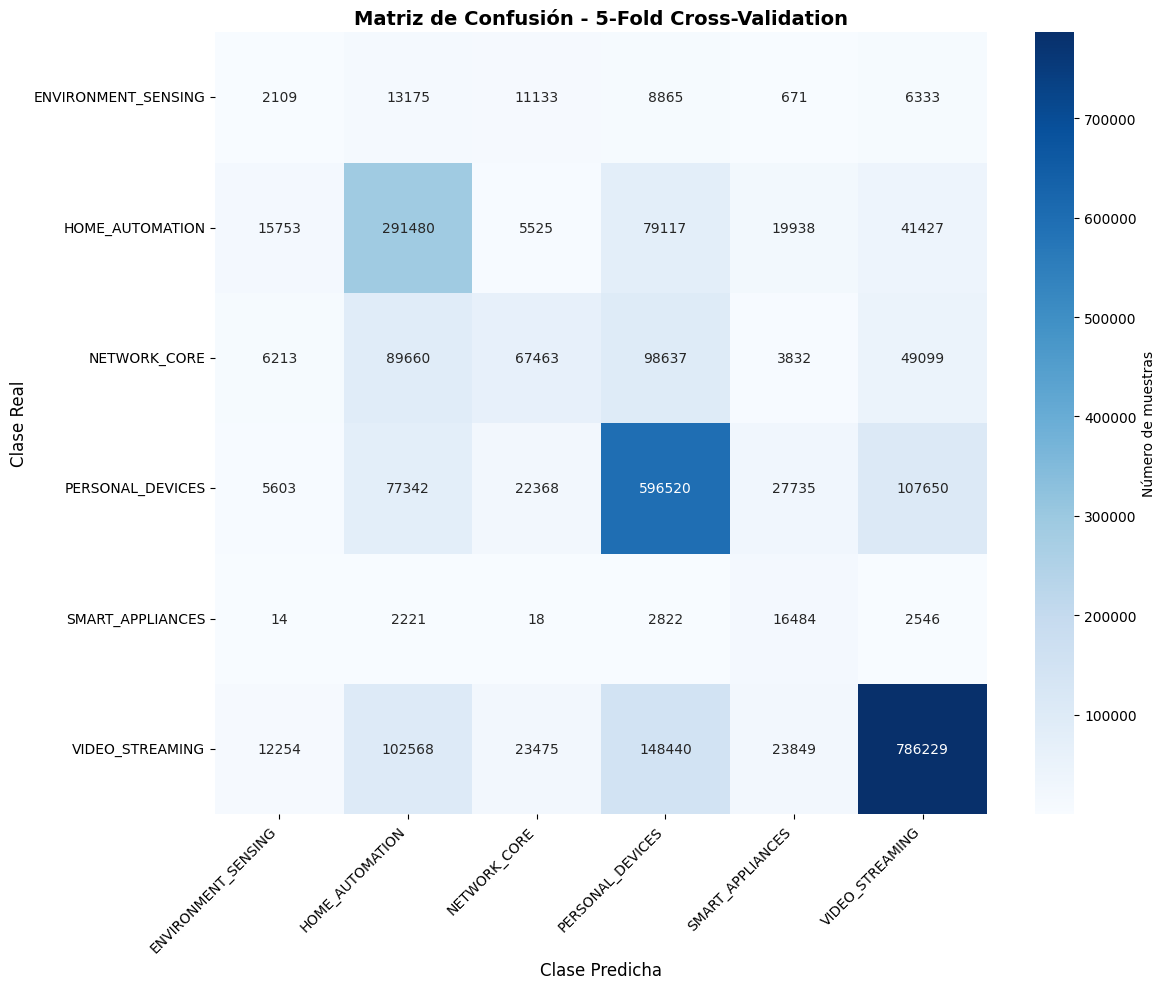

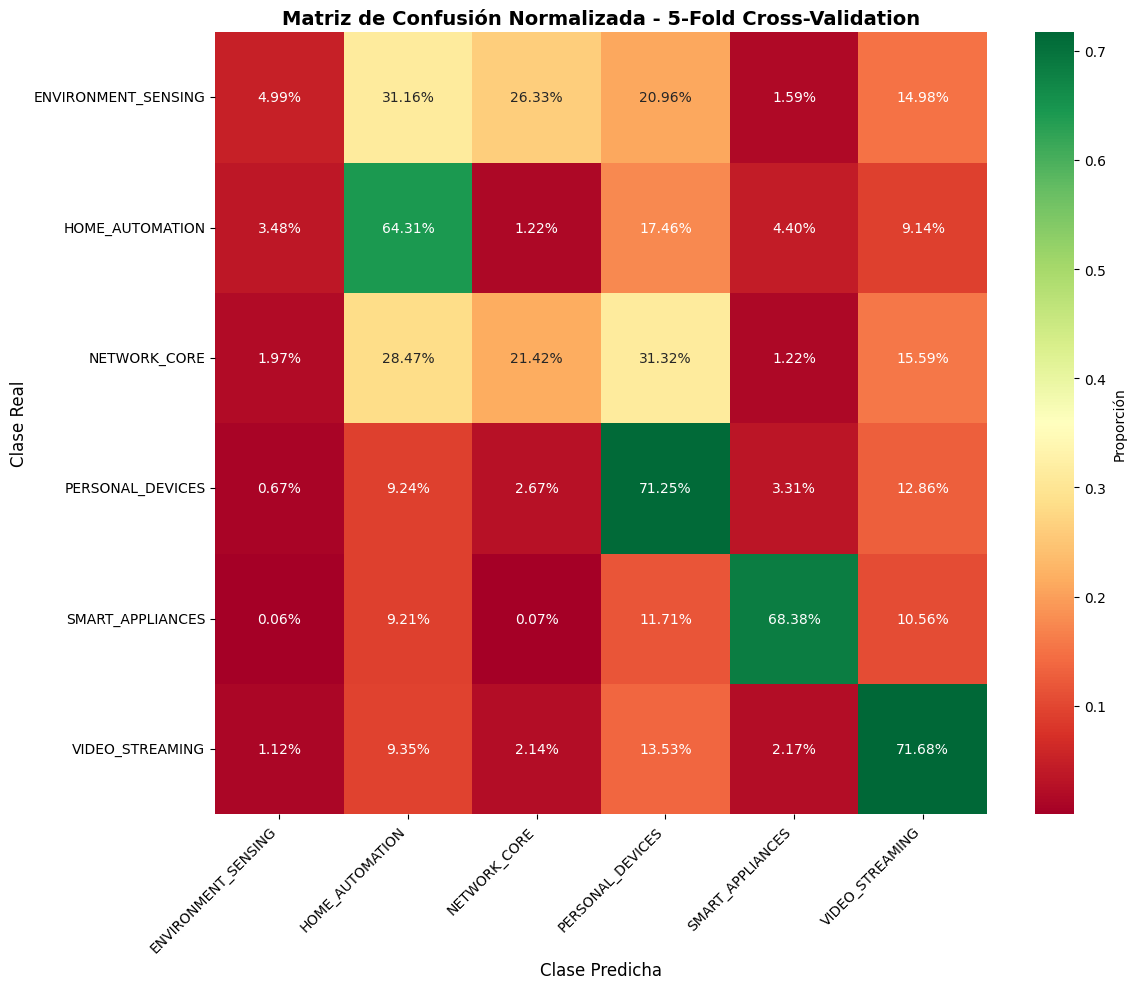


=== ESTADÍSTICAS POR CLASE ===
Clase                     | Muestras   | Precisión 
-------------------------------------------------------
ENVIRONMENT_SENSING       | 42286      |   4.99%
HOME_AUTOMATION           | 453240     |  64.31%
NETWORK_CORE              | 314904     |  21.42%
PERSONAL_DEVICES          | 837218     |  71.25%
SMART_APPLIANCES          | 24105      |  68.38%
VIDEO_STREAMING           | 1096815    |  71.68%


In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz de Confusión Agregada de todos los folds
print("=== MATRIZ DE CONFUSIÓN AGREGADA (Todos los Folds) ===\n")

# Almacenar todas las predicciones y valores reales
all_y_true = []
all_y_pred = []

# Re-ejecutar cross-validation para recopilar predicciones
for test_idx in range(len(dfs)):
    # Seleccionar datasets de entrenamiento
    train_indices = [i for i in range(len(dfs)) if i != test_idx]
    train_dfs = [dfs[i] for i in train_indices]
    train_data = pd.concat(train_dfs, ignore_index=True)
    test_data = dfs[test_idx].copy()
    
    # Separar features y target
    X_train = train_data.drop(columns=['Type'])
    y_train = train_data['Type']
    X_test = test_data.drop(columns=['Type'])
    y_test = test_data['Type']
    
    # Entrenar y predecir
    rf = RandomForestClassifier(**rf_params)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    # Acumular predicciones
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

# Calcular matriz de confusión
cm = confusion_matrix(all_y_true, all_y_pred)

# Obtener nombres de clases
class_names = le.classes_

# Visualizar matriz de confusión
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Número de muestras'})
plt.title('Matriz de Confusión - 5-Fold Cross-Validation', fontsize=14, fontweight='bold')
plt.ylabel('Clase Real', fontsize=12)
plt.xlabel('Clase Predicha', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Matriz de confusión normalizada (porcentajes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Proporción'})
plt.title('Matriz de Confusión Normalizada - 5-Fold Cross-Validation', fontsize=14, fontweight='bold')
plt.ylabel('Clase Real', fontsize=12)
plt.xlabel('Clase Predicha', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Estadísticas por clase
print("\n=== ESTADÍSTICAS POR CLASE ===")
print(f"{'Clase':<25} | {'Muestras':<10} | {'Precisión':<10}")
print("-" * 55)
for i, class_name in enumerate(class_names):
    total_samples = cm[i].sum()
    correct = cm[i, i]
    precision = (correct / total_samples * 100) if total_samples > 0 else 0
    print(f"{class_name:<25} | {total_samples:<10} | {precision:>6.2f}%")

# Guardar Modelo

In [ ]:
# Entrenar modelo final con todos los datos y guardarlo
import joblib
from sklearn.ensemble import RandomForestClassifier

print("="*70)
print("=== ENTRENAMIENTO DEL MODELO FINAL CON TODOS LOS DATOS ===")
print("="*70)

# Concatenar todos los datasets
all_data = pd.concat(dfs, ignore_index=True)
print(f"\n📊 Dataset completo: {all_data.shape}")
print(f"   Muestras totales: {len(all_data):,}")
print(f"   Features: {all_data.shape[1] - 1}")
print(f"   Clases: {len(all_data['Type'].unique())}")

# Separar features y target
X = all_data.drop(columns=['Type'])
y = all_data['Type']

print(f"\n🔧 Entrenando Random Forest...")
print(f"   Parámetros: {rf_params}")

# Entrenar el modelo final
final_model = RandomForestClassifier(**rf_params)

final_model.fit(X, y)

# Guardar el modelo y el encoder
model_filename = 'iot_device_classifier_rf.pkl'
encoder_filename = 'label_encoder.pkl'

joblib.dump(final_model, model_filename)
joblib.dump(le, encoder_filename)

print(f"\n✅ Modelo entrenado exitosamente!")
print(f"   Archivo del modelo: {model_filename}")
print(f"   Archivo del encoder: {encoder_filename}")

# Información adicional del modelo
print(f"\n📈 Información del modelo:")
print(f"   Número de árboles: {final_model.n_estimators}")
print(f"   Profundidad máxima: {final_model.max_depth}")
print(f"   Features usados: {final_model.n_features_in_}")
print(f"   Clases: {le.classes_}")

# Accuracy en el conjunto completo (como referencia)
y_pred_train = final_model.predict(X)
train_acc = accuracy_score(y, y_pred_train)
print(f"\n   Accuracy en datos de entrenamiento: {train_acc:.4f}")

print("\n" + "="*70)
print("Para cargar el modelo más tarde, usa:")
print("  model = joblib.load('iot_device_classifier_rf.pkl')")
print("  encoder = joblib.load('label_encoder.pkl')")
print("="*70)


=== ENTRENAMIENTO DEL MODELO FINAL CON TODOS LOS DATOS ===

📊 Dataset completo: (2768568, 80)
   Muestras totales: 2,768,568
   Features: 79
   Clases: 5

🔧 Entrenando Random Forest...
   Parámetros: n_estimators=50, max_depth=15, n_jobs=-1

✅ Modelo entrenado exitosamente!
   Archivo del modelo: iot_device_classifier_rf.pkl
   Archivo del encoder: label_encoder.pkl

📈 Información del modelo:
   Número de árboles: 50
   Profundidad máxima: 15
   Features usados: 79
   Clases: ['APPLIANCES' 'COMPUTING' 'CONTROL' 'SENSORS' 'STREAMING']

   Accuracy en datos de entrenamiento: 0.9198

Para cargar el modelo más tarde, usa:
  model = joblib.load('iot_device_classifier_rf.pkl')
  encoder = joblib.load('label_encoder.pkl')
